In [395]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt 

In [396]:
df = pd.read_csv('../data/interim/disease_symptom.csv')
df

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
...,...,...,...,...,...,...,...,...,...,...
344,Stroke,Yes,No,Yes,No,80,Female,High,High,Positive
345,Stroke,Yes,No,Yes,No,85,Male,High,High,Positive
346,Stroke,Yes,No,Yes,No,85,Male,High,High,Positive
347,Stroke,Yes,No,Yes,No,90,Female,High,High,Positive


In [397]:
df.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive


In [398]:
df.dtypes

Disease                 object
Fever                   object
Cough                   object
Fatigue                 object
Difficulty Breathing    object
Age                      int64
Gender                  object
Blood Pressure          object
Cholesterol Level       object
Outcome Variable        object
dtype: object

In [399]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

str_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in str_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [400]:
df.head()

,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level,outcome_variable
0,influenza,yes,no,yes,yes,19,female,low,normal,positive
1,common_cold,no,yes,yes,no,25,female,normal,normal,negative
2,eczema,no,yes,yes,no,25,female,normal,normal,negative
3,asthma,yes,yes,no,yes,25,male,normal,normal,positive
4,asthma,yes,yes,no,yes,25,male,normal,normal,positive


In [401]:
df.head().isnull().sum()

disease                 0
fever                   0
cough                   0
fatigue                 0
difficulty_breathing    0
age                     0
gender                  0
blood_pressure          0
cholesterol_level       0
outcome_variable        0
dtype: int64

In [402]:
df.outcome_variable == 'positive'


0       True
1      False
2      False
3       True
4       True
       ...  
344     True
345     True
346     True
347     True
348     True
Name: outcome_variable, Length: 349, dtype: bool

In [403]:
# VALIDATION

In [404]:
from sklearn.model_selection import train_test_split

In [405]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [406]:
len(df_full_train), len(df_test)

(279, 70)

In [407]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [408]:
y_train = df_train.outcome_variable.values
y_val = df_val.outcome_variable.values
y_test = df_test.outcome_variable.values

In [409]:
del df_train['outcome_variable']
del df_val['outcome_variable']
del df_test['outcome_variable']

In [410]:
# EDA

In [411]:
df_full_train = df_full_train.reset_index(drop=True)

In [412]:
df_full_train.outcome_variable.value_counts(normalize=True)

outcome_variable
positive    0.512545
negative    0.487455
Name: proportion, dtype: float64

In [413]:
df_full_train.outcome_variable = (df.outcome_variable == 'positive').astype(int)

In [414]:
global_disease_rate = df_full_train.outcome_variable.mean()
round(global_disease_rate, 4)

np.float64(0.4982)

In [415]:
df_full_train

,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level,outcome_variable
0,diabetes,yes,yes,yes,no,65,female,normal,high,1
1,migraine,no,yes,yes,no,30,female,normal,normal,0
2,asthma,no,yes,yes,yes,35,female,high,normal,0
3,osteoporosis,yes,no,yes,no,60,male,high,normal,1
4,crohn's_disease,yes,yes,yes,no,45,female,high,high,1
...,...,...,...,...,...,...,...,...,...,...
274,hypothyroidism,no,no,yes,no,48,male,normal,high,0
275,parkinson's_disease,no,no,yes,no,55,female,normal,low,0
276,rubella,yes,no,yes,no,35,female,high,normal,0
277,pancreatic_cancer,no,no,yes,no,50,female,high,high,0


In [416]:

numerical = ['age']
categorical = [
    'disease',
    'fever',
    'cough',
    'fatigue',
    'difficulty_breathing',
    'gender',
    'blood_pressure',
    'cholesterol_level',
               ]

In [417]:
df_full_train[categorical].nunique()

disease                 104
fever                     2
cough                     2
fatigue                   2
difficulty_breathing      2
gender                    2
blood_pressure            3
cholesterol_level         3
dtype: int64

In [418]:
# Feature Importance

In [419]:
df_full_train.head()

,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level,outcome_variable
0,diabetes,yes,yes,yes,no,65,female,normal,high,1
1,migraine,no,yes,yes,no,30,female,normal,normal,0
2,asthma,no,yes,yes,yes,35,female,high,normal,0
3,osteoporosis,yes,no,yes,no,60,male,high,normal,1
4,crohn's_disease,yes,yes,yes,no,45,female,high,high,1


In [420]:
disease_female = df_full_train[df_full_train.gender == 'female'].outcome_variable.mean()
print(disease_female)

0.5035460992907801


In [421]:
disease_male = df_full_train[df_full_train.gender == 'male'].outcome_variable.mean()
print(disease_male)

0.4927536231884058


In [422]:
global_disease = df_full_train.outcome_variable.mean()
print(global_disease)

0.4982078853046595


In [423]:
df_full_train.fever.value_counts()

fever
no     142
yes    137
Name: count, dtype: int64

In [424]:
disease_with_fever = df_full_train[df_full_train.fever == 'yes'].outcome_variable.mean()
print(disease_with_fever)

0.49635036496350365


In [425]:
print(global_disease - disease_with_fever)


0.0018575203411558272


In [426]:
disease_without_fever = df_full_train[df_full_train.fever == 'no'].outcome_variable.mean()
print(disease_without_fever)

0.5


In [427]:
print(global_disease - disease_without_fever)

-0.0017921146953405187


In [428]:
disease_with_cough = df_full_train[df_full_train.cough == 'yes'].outcome_variable.mean()
print(disease_with_cough)

0.5547445255474452


In [429]:
print(global_disease - disease_with_cough)

-0.05653664024278576


In [430]:
disease_without_cough = df_full_train[df_full_train.cough == 'no'].outcome_variable.mean()
print(disease_without_cough)

0.44366197183098594


In [431]:
print(global_disease - disease_without_cough)

0.054545913473673546


In [432]:
disease_with_fatigue = df_full_train[df_full_train.fatigue == 'yes'].outcome_variable.mean()
print(disease_with_fatigue)

0.484375


In [433]:
print(global_disease - disease_with_fatigue)

0.013832885304659481


In [434]:
disease_without_fatigue = df_full_train[df_full_train.fatigue == 'no'].outcome_variable.mean()
print(disease_without_fatigue)

0.5287356321839081


In [435]:
print(global_disease - disease_without_fatigue)

-0.030527746879248585


In [436]:
# RISK RATIO

In [437]:
print(disease_with_cough / global_disease)

1.1134800189045844


In [438]:
print(disease_without_cough / global_disease)

0.8905157564089574


In [439]:
from IPython.display import display

In [440]:

for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).outcome_variable.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_disease
    df_group['risk'] = df_group['mean'] / global_disease
    display(df_group)
    print()
    print()

disease


,mean,count,diff,risk
disease,,,,
allergic_rhinitis,0.50,4,0.001792,1.003597
alzheimer's_disease,0.20,5,-0.298208,0.401439
anemia,1.00,1,0.501792,2.007194
anxiety_disorders,0.25,4,-0.248208,0.501799
appendicitis,0.00,1,-0.498208,0.000000
...,...,...,...,...
turner_syndrome,1.00,1,0.501792,2.007194
ulcerative_colitis,0.75,4,0.251792,1.505396
urinary_tract_infection,0.50,4,0.001792,1.003597




fever


,mean,count,diff,risk
fever,,,,
no,0.50000,142,0.001792,1.003597
yes,0.49635,137,-0.001858,0.996272




cough


...

,mean,count,diff,risk
gender,,,,
female,0.503546,141,0.005338,1.010715
male,0.492754,138,-0.005454,0.989052




blood_pressure


,mean,count,diff,risk
blood_pressure,,,,
high,0.523438,128,0.025230,1.050641
low,0.352941,17,-0.145267,0.708421
normal,0.492537,134,-0.005671,0.988618




cholesterol_level


,mean,count,diff,risk
cholesterol_level,,,,
high,0.518248,137,0.020040,1.040225
low,0.440000,25,-0.058208,0.883165
normal,0.487179,117,-0.011028,0.977864


In [441]:
# Feature importance: Mutual Information

In [442]:
from sklearn.metrics import mutual_info_score

In [443]:
mutual_info_score(df_full_train.outcome_variable, df_full_train.disease)

np.float64(0.2310807643592562)

In [444]:
mutual_info_score(df_full_train.outcome_variable, df_full_train.difficulty_breathing)

np.float64(0.003481071465758545)

In [445]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.outcome_variable)

In [446]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

disease                 0.231081
cough                   0.006180
difficulty_breathing    0.003481
blood_pressure          0.003226
cholesterol_level       0.001105
fatigue                 0.000845
gender                  0.000058
fever                   0.000007
dtype: float64

In [447]:
# Feature Importance: Correlation

In [448]:
df_full_train.age.max()

np.int64(85)

In [449]:
df_full_train[numerical].corrwith(df_full_train.outcome_variable).abs()

age    0.021108
dtype: float64

In [450]:
df_full_train[df_full_train.age <= 37].outcome_variable.mean()

np.float64(0.569620253164557)

In [451]:
df_full_train[(df_full_train.age > 37) & (df_full_train.age <= 50)].outcome_variable.mean()

np.float64(0.45689655172413796)

In [452]:
# One-Hot Encoding

In [453]:
from sklearn.feature_extraction import DictVectorizer

In [454]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')

In [455]:
dv = DictVectorizer(sparse=False)

In [456]:
x_train = dv.fit_transform(train_dicts)

In [457]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

In [458]:
x_val = dv.transform(val_dicts)

In [459]:
# Training model

In [460]:
from sklearn.linear_model import LogisticRegression

In [461]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [462]:
model.intercept_[0]

np.float64(-0.7670651250119769)

In [463]:
y_pred = model.predict_proba(x_val)[:, 1]

In [464]:
y_pred

array([0.50426763, 0.78473504, 0.79857928, 0.27018401, 0.82530995,
       0.93686071, 0.67131867, 0.23988917, 0.571299  , 0.06482929,
       0.27618428, 0.40920843, 0.52195929, 0.55282646, 0.72075251,
       0.25926506, 0.72144635, 0.27280279, 0.31292731, 0.5903144 ,
       0.80171427, 0.08836426, 0.73307704, 0.16734079, 0.47564237,
       0.29239796, 0.62208312, 0.60742828, 0.7376095 , 0.33962832,
       0.69415036, 0.56624936, 0.69038241, 0.67552279, 0.67905486,
       0.51055564, 0.70205918, 0.84931144, 0.3995439 , 0.12805984,
       0.19938748, 0.9038867 , 0.69415036, 0.5388728 , 0.56208425,
       0.83715039, 0.54381994, 0.42206212, 0.7074253 , 0.24860174,
       0.74035578, 0.88101902, 0.83776238, 0.52129898, 0.82077772,
       0.24511322, 0.70924168, 0.86472499, 0.46575676, 0.59935854,
       0.25567783, 0.08539677, 0.17355016, 0.49570171, 0.55917708,
       0.82077772, 0.89464517, 0.67758339, 0.50029285, 0.85038665])

In [465]:
disease_decision = (y_pred > 0.5)


In [466]:
df_val[disease_decision]

,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level
0,diabetes,no,yes,no,no,55,female,normal,high
1,cholera,yes,no,yes,yes,50,female,high,high
2,gastroenteritis,yes,yes,yes,no,30,male,high,high
4,tuberculosis,yes,yes,yes,yes,40,male,high,high
5,pneumonia,yes,yes,yes,yes,40,female,normal,high
6,rubella,yes,no,yes,no,35,female,high,normal
8,tourette_syndrome,no,no,yes,no,65,male,high,high
12,melanoma,yes,no,yes,no,45,male,high,normal
13,turner_syndrome,no,no,yes,no,45,male,high,high
14,stroke,yes,yes,yes,yes,29,female,normal,normal


In [467]:
y_pred

array([0.50426763, 0.78473504, 0.79857928, 0.27018401, 0.82530995,
       0.93686071, 0.67131867, 0.23988917, 0.571299  , 0.06482929,
       0.27618428, 0.40920843, 0.52195929, 0.55282646, 0.72075251,
       0.25926506, 0.72144635, 0.27280279, 0.31292731, 0.5903144 ,
       0.80171427, 0.08836426, 0.73307704, 0.16734079, 0.47564237,
       0.29239796, 0.62208312, 0.60742828, 0.7376095 , 0.33962832,
       0.69415036, 0.56624936, 0.69038241, 0.67552279, 0.67905486,
       0.51055564, 0.70205918, 0.84931144, 0.3995439 , 0.12805984,
       0.19938748, 0.9038867 , 0.69415036, 0.5388728 , 0.56208425,
       0.83715039, 0.54381994, 0.42206212, 0.7074253 , 0.24860174,
       0.74035578, 0.88101902, 0.83776238, 0.52129898, 0.82077772,
       0.24511322, 0.70924168, 0.86472499, 0.46575676, 0.59935854,
       0.25567783, 0.08539677, 0.17355016, 0.49570171, 0.55917708,
       0.82077772, 0.89464517, 0.67758339, 0.50029285, 0.85038665])

In [468]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = disease_decision
df_pred['actual'] = y_val
df_pred

,probability,prediction,actual
0,0.504268,True,negative
1,0.784735,True,negative
2,0.798579,True,negative
3,0.270184,False,negative
4,0.825310,True,positive
...,...,...,...
65,0.820778,True,negative
66,0.894645,True,positive
67,0.677583,True,positive
68,0.500293,True,positive


In [469]:
df_pred['correct'] = df_pred.prediction == df_pred.actual.map({'negative': 0, 'positive': 1})
df_pred['correct'] = df_pred['correct'].astype(int)

df_pred


,probability,prediction,actual,correct
0,0.504268,True,negative,0
1,0.784735,True,negative,0
2,0.798579,True,negative,0
3,0.270184,False,negative,1
4,0.825310,True,positive,1
...,...,...,...,...
65,0.820778,True,negative,0
66,0.894645,True,positive,1
67,0.677583,True,positive,1
68,0.500293,True,positive,1


In [470]:
df_pred.correct.mean()

np.float64(0.7)

In [471]:
disease_decision.astype(int)

array([1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1])

In [472]:
# Using Model

In [473]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')

In [474]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

In [475]:
y_full_train = df_full_train.outcome_variable.values

In [476]:
model = LogisticRegression()
model.fit(X_full_train, y_full_train)

LogisticRegression()

In [477]:
dicts_test = df_test[categorical + numerical].to_dict(orient='records')

In [478]:
X_test = dv.transform(dicts_test)

In [479]:
y_pred = model.predict_proba(X_test)[:, 1]

In [480]:
disease_decision = (y_pred >= 0.5)

In [481]:
y_test

array(['positive', 'negative', 'negative', 'negative', 'positive',
       'negative', 'negative', 'negative', 'positive', 'positive',
       'negative', 'positive', 'positive', 'negative', 'positive',
       'negative', 'positive', 'negative', 'negative', 'positive',
       'positive', 'positive', 'negative', 'positive', 'negative',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'negative', 'positive', 'negative', 'positive', 'negative',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'negative', 'positive',
       'negative', 'positive', 'negative', 'positive', 'positive',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'negative', 'negative',
       'negative', 'negative', 'positive', 'positive', 'positive'],
      dtype=object)

In [482]:
df_pred_use = pd.DataFrame()
df_pred_use['probability'] = y_pred
df_pred_use['prediction'] = disease_decision
df_pred_use['test'] = y_test
df_pred_use

,probability,prediction,test
0,0.645109,True,positive
1,0.340878,False,negative
2,0.223638,False,negative
3,0.389327,False,negative
4,0.526287,True,positive
...,...,...,...
65,0.743464,True,negative
66,0.530587,True,negative
67,0.353136,False,positive
68,0.351667,False,positive


In [483]:
df_pred_use['correct'] = df_pred_use.prediction == df_pred_use.test.map({'negative': 0, 'positive': 1})
df_pred_use['correct'] = df_pred_use['correct'].astype(int)

df_pred_use

,probability,prediction,test,correct
0,0.645109,True,positive,1
1,0.340878,False,negative,1
2,0.223638,False,negative,1
3,0.389327,False,negative,1
4,0.526287,True,positive,1
...,...,...,...,...
65,0.743464,True,negative,0
66,0.530587,True,negative,0
67,0.353136,False,positive,0
68,0.351667,False,positive,0


In [484]:
df_pred_use.correct.mean()

np.float64(0.5714285714285714)

In [485]:
y_test

array(['positive', 'negative', 'negative', 'negative', 'positive',
       'negative', 'negative', 'negative', 'positive', 'positive',
       'negative', 'positive', 'positive', 'negative', 'positive',
       'negative', 'positive', 'negative', 'negative', 'positive',
       'positive', 'positive', 'negative', 'positive', 'negative',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'negative', 'positive', 'negative', 'positive', 'negative',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'negative', 'positive',
       'negative', 'positive', 'negative', 'positive', 'positive',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'negative', 'negative',
       'negative', 'negative', 'positive', 'positive', 'positive'],
      dtype=object)

In [486]:
disease = dicts_test[-1]
disease

{'disease': 'stroke',
 'fever': 'yes',
 'cough': 'no',
 'fatigue': 'yes',
 'difficulty_breathing': 'no',
 'gender': 'female',
 'blood_pressure': 'high',
 'cholesterol_level': 'high',
 'age': 90}

In [487]:
X_small = dv.transform([disease])

In [488]:
model.predict_proba(X_small)[0, 1]

np.float64(0.5384316667921175)

In [489]:
y_test[-1]

'positive'

In [490]:
# Decision Tree

In [491]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [492]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

In [493]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [494]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [495]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [496]:
y_pred = dt.predict_proba(X_val)[:, 1]

In [497]:
roc_auc_score(y_val, y_pred)

np.float64(0.7113022113022113)

In [498]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

np.float64(1.0)

In [499]:
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

In [500]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train:', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val:', auc)

train: 0.7136363636363636
val: 0.7514332514332515


In [501]:
from sklearn.tree import export_text

In [502]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- cholesterol_level=high <= 0.50
|   |--- fever=no <= 0.50
|   |   |--- class: positive
|   |--- fever=no >  0.50
|   |   |--- class: negative
|--- cholesterol_level=high >  0.50
|   |--- disease=osteoporosis <= 0.50
|   |   |--- class: positive
|   |--- disease=osteoporosis >  0.50
|   |   |--- class: negative



In [503]:
# Decision Tree Parameter Tuning

In [504]:
for d in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    print('%4s -> %.3f' % (d, auc))

   1 -> 0.730
   2 -> 0.751
   3 -> 0.570
   4 -> 0.740
   5 -> 0.809
   6 -> 0.803
  10 -> 0.739
  15 -> 0.711
  20 -> 0.738
None -> 0.663


In [505]:
scores = []

for d in [4, 5, 6, 7, 10, 15, 20, None]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, s, auc))

In [506]:
columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,max_depth,min_samples_leaf,auc
0,4.0,1,0.764128
1,4.0,2,0.722768
2,4.0,5,0.757985
3,4.0,10,0.822277
4,4.0,15,0.745291


In [507]:
df_scores.sort_values(by='auc', ascending=False).head()

,max_depth,min_samples_leaf,auc
9,5.0,1,0.832105
27,7.0,1,0.829648
5,4.0,20,0.828010
50,15.0,20,0.828010
14,5.0,20,0.828010


In [508]:
df_scores

,max_depth,min_samples_leaf,auc
0,4.0,1,0.764128
1,4.0,2,0.722768
2,4.0,5,0.757985
3,4.0,10,0.822277
4,4.0,15,0.745291
...,...,...,...
67,NaN,15,0.745291
68,NaN,20,0.828010
69,NaN,100,0.730139
70,NaN,200,0.500000


In [509]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', 
                                  columns=['max_depth'],
                                  values=['auc'])

df_scores_pivot.round(3)

auc                                                 
max_depth           NaN   4.0    5.0    6.0    7.0    10.0   15.0   20.0
min_samples_leaf                                                        
1                 0.738  0.764  0.832  0.794  0.830  0.742  0.794  0.738
2                 0.816  0.723  0.811  0.803  0.740  0.787  0.800  0.795
5                 0.765  0.758  0.775  0.752  0.766  0.765  0.775  0.765
10                0.794  0.822  0.794  0.794  0.794  0.794  0.794  0.794
15                0.745  0.745  0.745  0.745  0.745  0.745  0.745  0.745
20                0.828  0.828  0.828  0.828  0.828  0.828  0.828  0.828
100               0.730  0.730  0.730  0.730  0.730  0.730  0.730  0.730
200               0.500  0.500  0.500  0.500  0.500  0.500  0.500  0.500
500               0.500  0.500  0.500  0.500  0.500  0.500  0.500  0.500

In [510]:
import seaborn as sns 

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

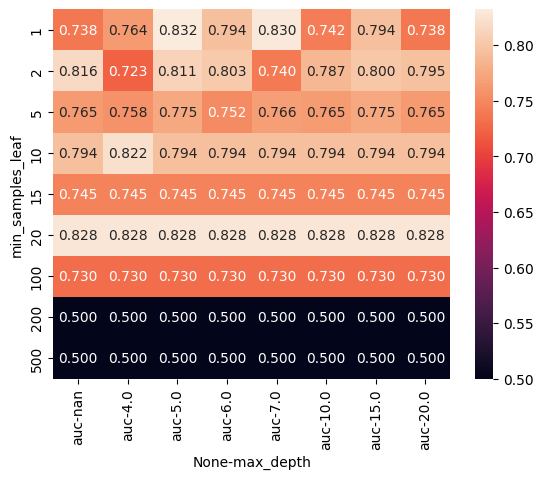

In [511]:
sns.heatmap(df_scores_pivot, annot=True, fmt='.3f')

In [512]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)

In [513]:
# Random Forest

In [514]:
from sklearn.ensemble import RandomForestClassifier

In [515]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=1)

In [516]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.8521703521703522)

In [517]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

In [518]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])

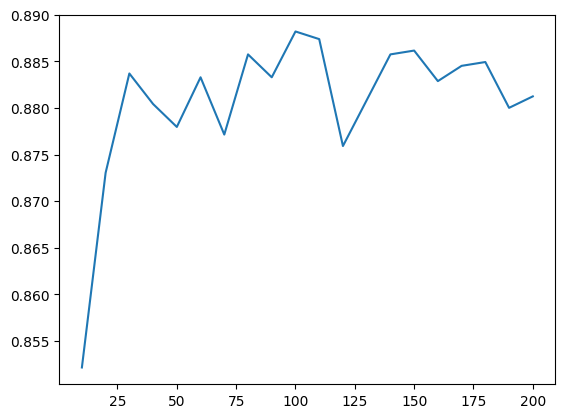

In [519]:
plt.plot(df_scores.n_estimators, df_scores.auc)

In [520]:
scores = []

for d in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=d,
                                    random_state=1)
        
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))

In [521]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,max_depth,n_estimators,auc
0,5,10,0.771908
1,5,20,0.808763
2,5,30,0.836200
3,5,40,0.830467
4,5,50,0.829648


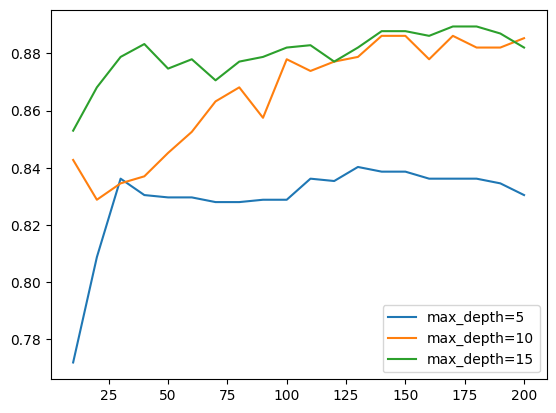

In [522]:
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc,
             label='max_depth=%d' % d)

plt.legend()

In [523]:
max_depth = 10

In [524]:
scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=1)
        
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))

In [525]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,min_samples_leaf,n_estimators,auc
0,1,10,0.842752
1,1,20,0.828829
2,1,30,0.834562
3,1,40,0.837019
4,1,50,0.845209


In [526]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]
list(zip(min_samples_leaf_values, colors))

[(1, 'black'), (3, 'blue'), (5, 'orange'), (10, 'red'), (50, 'grey')]

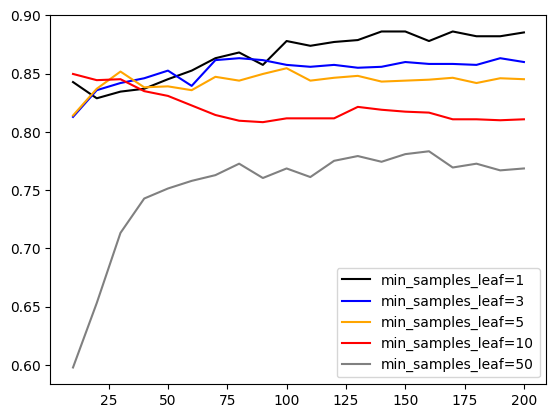

In [527]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]

for s, col in zip(min_samples_leaf_values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)

plt.legend()

In [528]:
min_samples_leaf = 1

In [529]:
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1,
                            n_jobs=-1)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=1)

In [530]:
# Tuning Random Forest

In [531]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.8779688779688779)

In [532]:
rf = RandomForestClassifier(n_estimators=10, min_samples_leaf=1)
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.8841113841113841)

In [533]:

aucs = []

for i in range(100):
    rf = RandomForestClassifier(n_estimators=10)
    rf.fit(X_train, y_train)
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    aucs.append(auc)

auc_mean = np.mean(aucs)
auc_std = np.std(aucs)

print('%.3f +- %.3f' % (auc_mean, auc_std))
print('%.3f -- %.3f' % (auc_mean -  auc_std, auc_mean + auc_std))

0.859 +- 0.025
0.834 -- 0.884


In [534]:
rf = RandomForestClassifier(n_estimators=10, random_state=3)
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.8701883701883703)

In [535]:
aucs = []

for i in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=i, random_state=3)
    rf.fit(X_train, y_train)
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    print('%s -> %.3f' % (i, auc))
    aucs.append(auc)

10 -> 0.870
20 -> 0.872
30 -> 0.880
40 -> 0.896
50 -> 0.898
60 -> 0.895
70 -> 0.892
80 -> 0.896
90 -> 0.896
100 -> 0.896
110 -> 0.901
120 -> 0.898
130 -> 0.900
140 -> 0.900
150 -> 0.900
160 -> 0.897
170 -> 0.896
180 -> 0.894
190 -> 0.894
200 -> 0.895


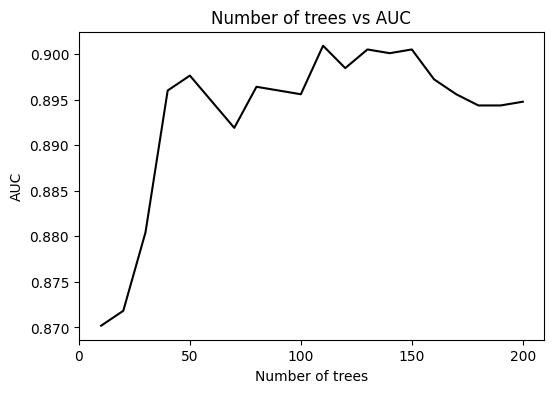

In [536]:
plt.figure(figsize=(6, 4))

plt.plot(range(10, 201, 10), aucs, color='black')
plt.xticks(range(0, 201, 50))

plt.title('Number of trees vs AUC')
plt.xlabel('Number of trees')
plt.ylabel('AUC')

# plt.savefig('ch06-figures/06_random_forest_n_estimators.svg')

plt.show()

In [537]:
all_aucs = {}

for depth in [5, 10, 20]:
    print('depth: %s' % depth)
    aucs = []

    for i in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=i, max_depth=depth, random_state=1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        print('%s -> %.3f' % (i, auc))
        aucs.append(auc)
    
    all_aucs[depth] = aucs
    print()
    

depth: 5
10 -> 0.772
20 -> 0.809
30 -> 0.836
40 -> 0.830
50 -> 0.830
60 -> 0.830
70 -> 0.828
80 -> 0.828
90 -> 0.829
100 -> 0.829
110 -> 0.836
120 -> 0.835
130 -> 0.840
140 -> 0.839
150 -> 0.839
160 -> 0.836
170 -> 0.836
180 -> 0.836
190 -> 0.835
200 -> 0.830

depth: 10
10 -> 0.843
20 -> 0.829
30 -> 0.835
40 -> 0.837
50 -> 0.845
60 -> 0.853
70 -> 0.863
80 -> 0.868
90 -> 0.857
100 -> 0.878
110 -> 0.874
120 -> 0.877
130 -> 0.879
140 -> 0.886
150 -> 0.886
160 -> 0.878
170 -> 0.886
180 -> 0.882
190 -> 0.882
200 -> 0.885

depth: 20
10 -> 0.849
20 -> 0.870
30 -> 0.882
40 -> 0.877
50 -> 0.877
60 -> 0.881
70 -> 0.871
80 -> 0.883
90 -> 0.879
100 -> 0.885
110 -> 0.885
120 -> 0.876
130 -> 0.880
140 -> 0.884
150 -> 0.885
160 -> 0.879
170 -> 0.884
180 -> 0.882
190 -> 0.878
200 -> 0.876



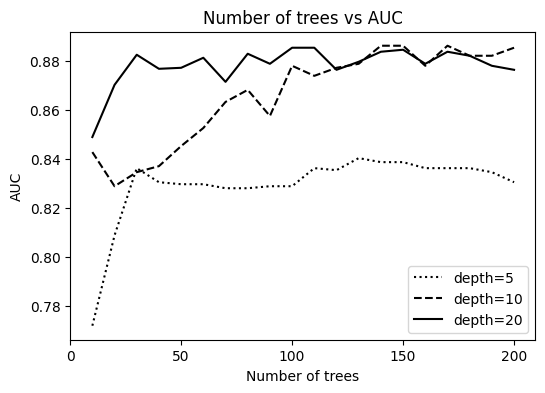

In [538]:
plt.figure(figsize=(6, 4))

num_trees = list(range(10, 201, 10))

plt.plot(num_trees, all_aucs[5], label='depth=5', color='black', linestyle='dotted')
plt.plot(num_trees, all_aucs[10], label='depth=10', color='black', linestyle='dashed')
plt.plot(num_trees, all_aucs[20], label='depth=20', color='black', linestyle='solid')
    
plt.xticks(range(0, 201, 50))
plt.legend()

plt.title('Number of trees vs AUC')
plt.xlabel('Number of trees')
plt.ylabel('AUC')

# plt.savefig('ch06-figures/06_random_forest_n_estimators_depth.svg')

plt.show()

In [539]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_estimators=200,
                       random_state=1)

In [540]:
y_pred_rf = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred_rf)

np.float64(0.8452088452088453)

In [541]:
from sklearn.metrics import roc_curve

In [542]:
y_pred_dt = dt.predict_proba(X_val)[:, 1]

In [543]:
y_val

array(['negative', 'negative', 'negative', 'negative', 'positive',
       'positive', 'negative', 'negative', 'negative', 'negative',
       'negative', 'positive', 'negative', 'negative', 'positive',
       'negative', 'negative', 'negative', 'negative', 'positive',
       'negative', 'negative', 'positive', 'negative', 'negative',
       'negative', 'positive', 'positive', 'positive', 'negative',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'negative', 'positive', 'negative', 'positive', 'negative',
       'positive', 'positive', 'positive', 'negative', 'negative',
       'positive', 'positive', 'negative', 'positive', 'negative',
       'positive', 'positive', 'positive', 'negative', 'negative',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'negative', 'negative', 'negative', 'negative', 'positive',
       'negative', 'positive', 'positive', 'positive', 'positive'],
      dtype=object)

In [544]:
rf_data_val = pd.DataFrame()
rf_data_val['vals_y'] = y_val
rf_data_val['vals_y'] = rf_data_val.vals_y.map({'negative': 0, 'positive': 1})
rf_val = rf_data_val['vals_y']
rf_val

0     0
1     0
2     0
3     0
4     1
     ..
65    0
66    1
67    1
68    1
69    1
Name: vals_y, Length: 70, dtype: int64

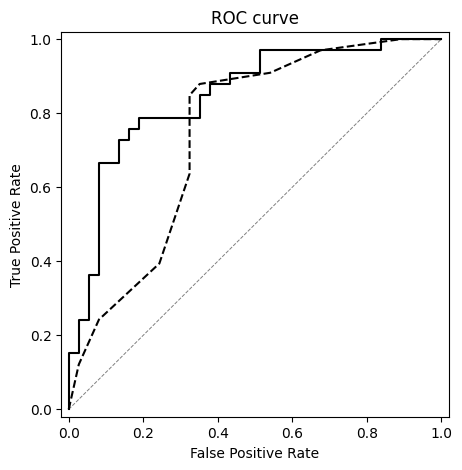

In [545]:
plt.figure(figsize=(5, 5))

fpr, tpr, _ = roc_curve(rf_data_val, y_pred_rf)
plt.plot(fpr, tpr, color='black')

fpr, tpr, _ = roc_curve(rf_data_val, y_pred_dt)
plt.plot(fpr, tpr, color='black', linestyle='dashed')

plt.plot([0, 1], [0, 1], color='black', lw=0.7, linestyle='dashed', alpha=0.5)

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC curve')

plt.show()

In [546]:
# XGBoost

In [547]:
import xgboost as xgb

In [548]:
rf_data_train = pd.DataFrame()
rf_data_train['train_y'] = y_train
rf_data_train['train_y'] = rf_data_train.train_y.map({'negative': 0, 'positive': 1})
rf_train = rf_data_train['train_y']
rf_train

0      0
1      0
2      0
3      1
4      0
      ..
204    0
205    1
206    1
207    0
208    0
Name: train_y, Length: 209, dtype: int64

In [549]:
dtrain = xgb.DMatrix(X_train, label=rf_train, feature_names=dv.feature_names_)
dval = xgb.DMatrix(X_val, label=rf_val, feature_names=dv.feature_names_)

In [550]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'nthread': 8,
    'seed': 1
}

In [551]:
model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [552]:
y_pred = model.predict(dval)
y_pred[:10]

array([0.7672198 , 0.4560656 , 0.9147086 , 0.27855507, 0.87671673,
       0.8720673 , 0.30502468, 0.32590264, 0.85270655, 0.09771382],
      dtype=float32)

In [553]:
roc_auc_score(rf_val, y_pred_rf)

np.float64(0.8452088452088453)

In [554]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [555]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,
    'seed': 1
}

In [556]:
model = xgb.train(xgb_params, dtrain,
                  num_boost_round=100,
                  evals=watchlist, verbose_eval=10)

[0]	train-auc:0.86772	val-auc:0.76536
[10]	train-auc:0.97782	val-auc:0.85135
[20]	train-auc:0.99192	val-auc:0.85463
[30]	train-auc:0.99550	val-auc:0.85749
[40]	train-auc:0.99826	val-auc:0.87142
[50]	train-auc:0.99853	val-auc:0.86896
[60]	train-auc:0.99890	val-auc:0.87551
[70]	train-auc:0.99908	val-auc:0.88452
[80]	train-auc:0.99936	val-auc:0.89025
[90]	train-auc:0.99954	val-auc:0.89189
[99]	train-auc:0.99954	val-auc:0.89189


In [557]:
%%capture output

model = xgb.train(xgb_params, dtrain,
                  num_boost_round=100,
                  evals=watchlist, verbose_eval=5)

In [558]:
def parse_xgb_output(output):
    tree = []
    aucs_train = []
    aucs_val = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        tree.append(it)
        aucs_train.append(train)
        aucs_val.append(val)

    return tree, aucs_train, aucs_val

In [563]:
tree, aucs_train, aucs_val = parse_xgb_output(output)

In [564]:
tree, _, aucs_val_eta_03 = parse_xgb_output(output)
print(max(aucs_val_eta_03))
print(max(zip(aucs_val_eta_03, tree)))

0.90008
(0.90008, 200)


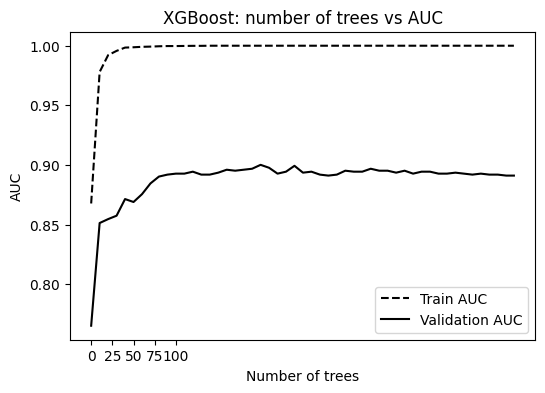

In [565]:
plt.figure(figsize=(6, 4))

plt.plot(tree, aucs_train, color='black', linestyle='dashed', label='Train AUC')
plt.plot(tree, aucs_val, color='black', linestyle='solid', label='Validation AUC')
plt.xticks(range(0, 101, 25))

plt.legend()

plt.title('XGBoost: number of trees vs AUC')
plt.xlabel('Number of trees')
plt.ylabel('AUC')

# plt.savefig('ch06-figures/06_xgb_default.svg')

plt.show()